
# Offline SSVEP-based BCI Multiclass Prediction

Building extended covariance matrices for SSVEP-based BCI. The
obtained matrices are shown. A Minimum Distance to Mean classifier
is trained to predict a 4-class problem for an offline setup.


In [3]:
# Authors: Sylvain Chevallier <sylvain.chevallier@uvsq.fr>,
# Emmanuel Kalunga, Quentin Barthélemy, David Ojeda
#
# License: BSD (3-clause)

import matplotlib.pyplot as plt
from mne import find_events, Epochs
from mne.io import Raw
import numpy as np
from sklearn.model_selection import cross_val_score, RepeatedKFold

from pyriemann.classification import MDM
from pyriemann.estimation import BlockCovariances
from pyriemann.utils.mean import mean_riemann
from helpers.ssvep_helpers import download_data, extend_signal



## Loading EEG data

The data are loaded through a MNE loader



In [4]:
# Download data
destination = download_data(subject=12, session=1)
# Read data in MNE Raw and numpy format
raw = Raw(destination, preload=True, verbose="ERROR")
events = find_events(raw, shortest_event=0, verbose=False)
raw = raw.pick("eeg")

event_id = {"13 Hz": 2, "17 Hz": 4, "21 Hz": 3, "resting-state": 1}
sfreq = int(raw.info["sfreq"])
eeg_data = raw.get_data()

Download complete in 00s (3.2 MB)


## Visualization of raw EEG data

Plot few seconds of signal from the `Oz` electrode using matplotlib



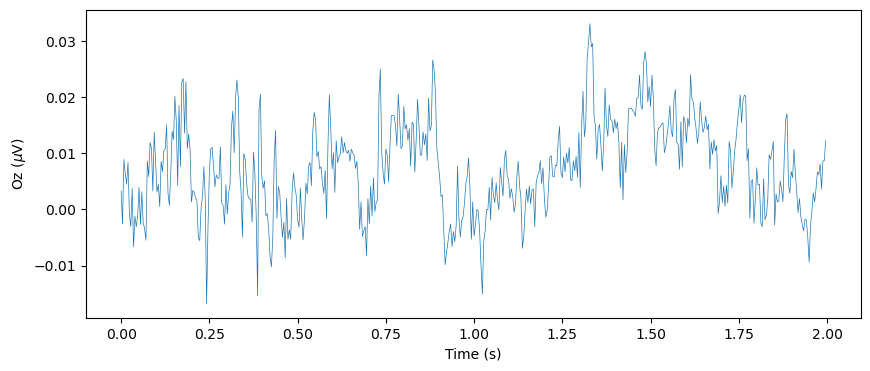

In [5]:
n_seconds = 2
time = np.linspace(0, n_seconds, n_seconds * sfreq,
                   endpoint=False)[np.newaxis, :]
plt.figure(figsize=(10, 4))
plt.plot(time.T, eeg_data[np.array(raw.ch_names) == "Oz", :n_seconds*sfreq].T,
         color="C0", lw=0.5)
plt.xlabel("Time (s)")
plt.ylabel(r"Oz ($\mu$V)")
plt.show()

And of all electrodes:



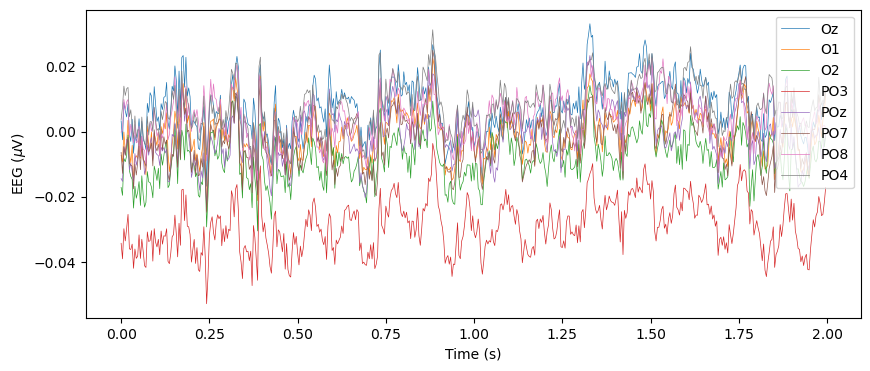

In [6]:
plt.figure(figsize=(10, 4))
for ch_idx, ch_name in enumerate(raw.ch_names):
    plt.plot(time.T, eeg_data[ch_idx, :n_seconds*sfreq].T, lw=0.5,
             label=ch_name)
plt.xlabel("Time (s)")
plt.ylabel(r"EEG ($\mu$V)")
plt.legend(loc="upper right")
plt.show()

With MNE, it is much easier to visualize the data



Using matplotlib as 2D backend.


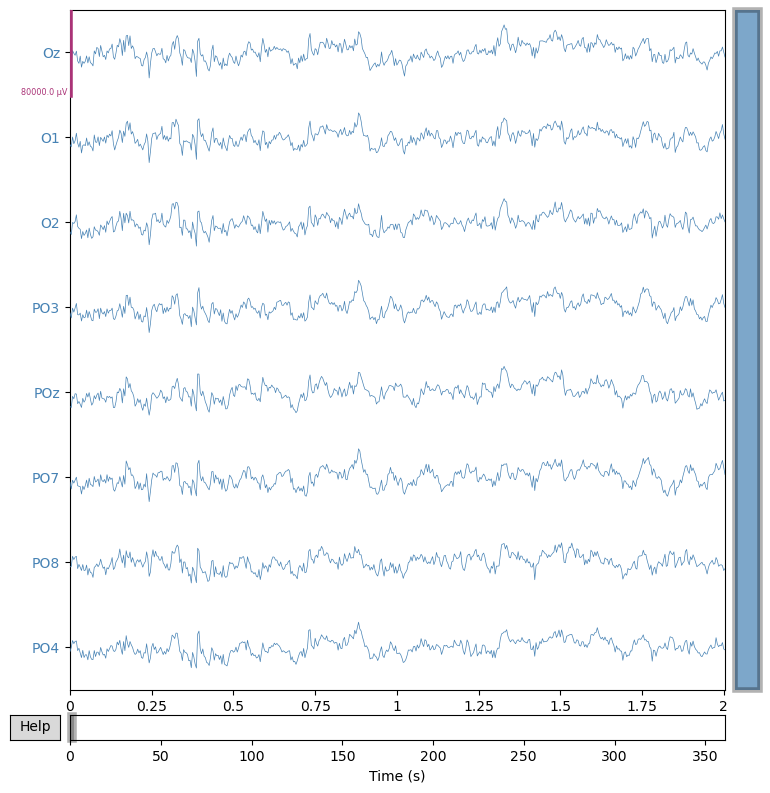

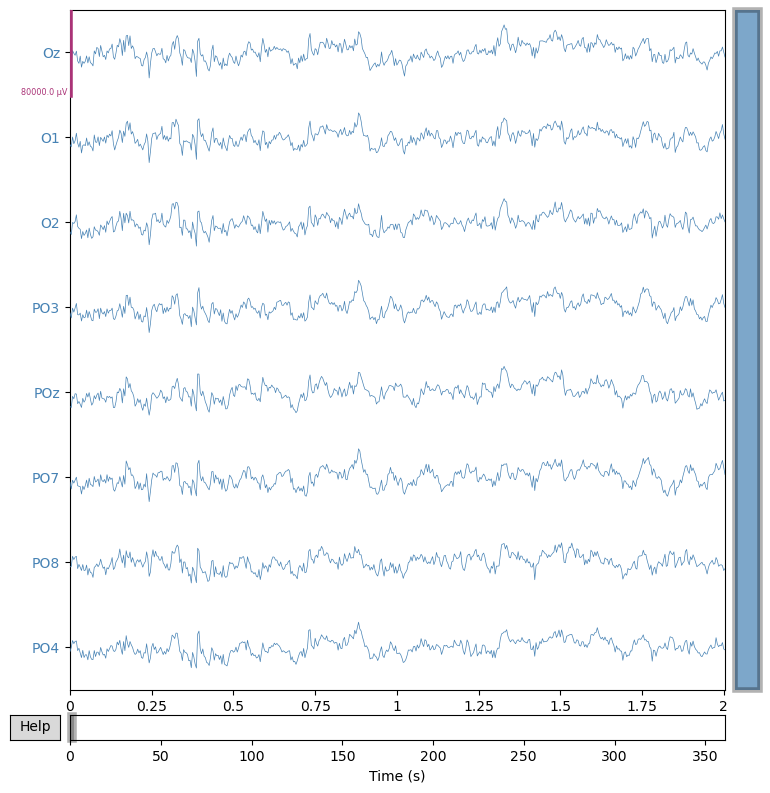

In [10]:
raw.plot(duration=n_seconds, start=0, n_channels=8, scalings={"eeg": 4e-2},
         color={"eeg": "steelblue"})

## Extended signals for spatial covariance

Using the approach proposed by [1]_, the SSVEP signal is extended to include
the filtered signals for each stimulation frequency. We stack the filtered
signals to build an extended signal.



In [ ]:
# We stack the filtered signals to build an extended signal
frequencies = [13, 17, 21]
freq_band = 0.1
raw_ext = extend_signal(raw, frequencies, freq_band)

Creating RawArray with float64 data, n_channels=24, n_times=92384
    Range : 0 ... 92383 =      0.000 ...   360.871 secs
Ready.


<RawArray | 24 x 92384 (360.9 s), ~16.9 MiB, data loaded>

Plot the extended signal



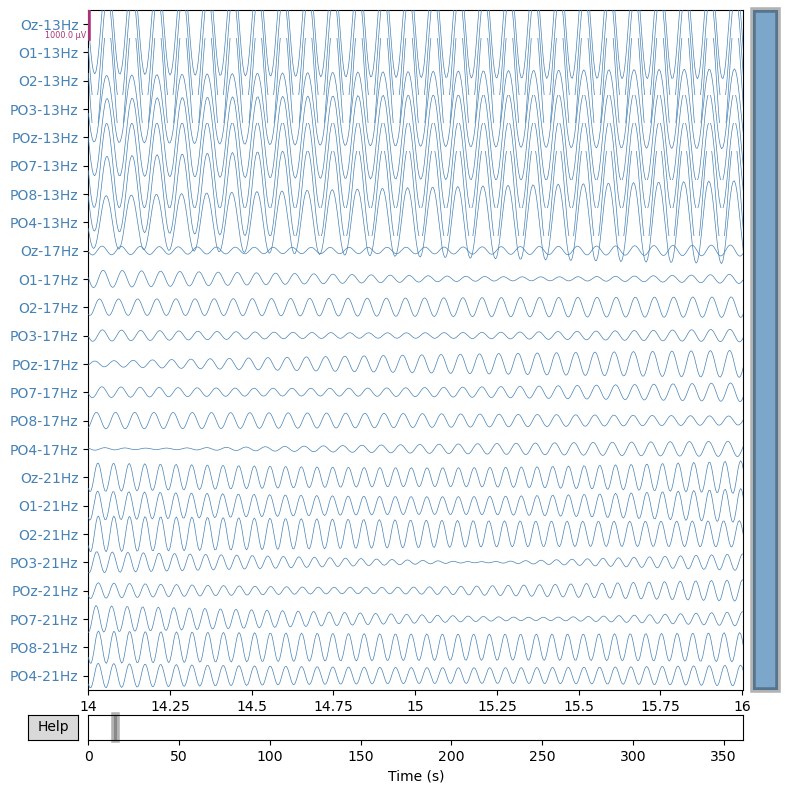

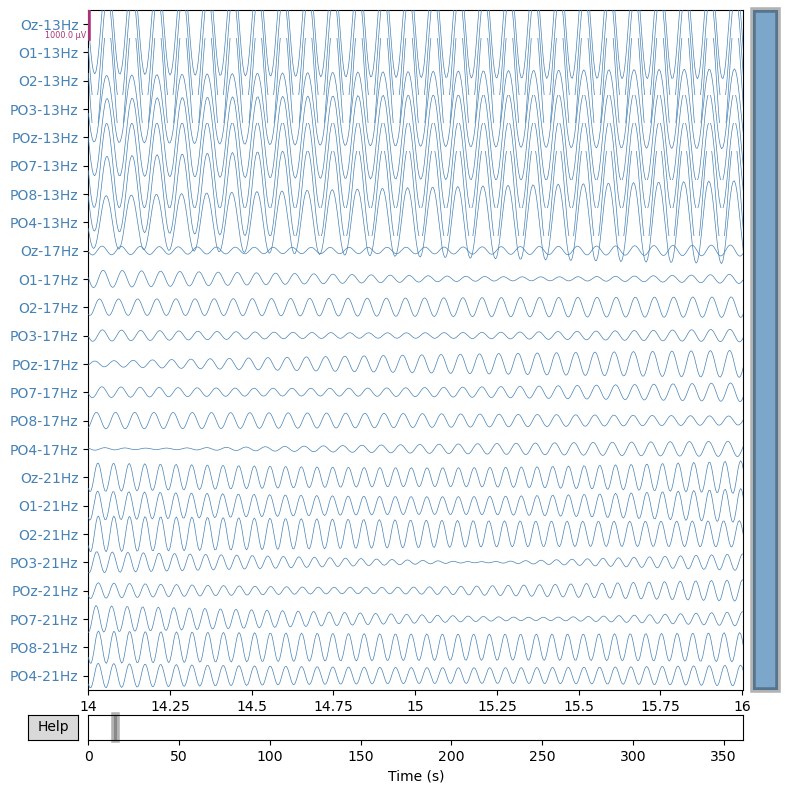

In [11]:
raw_ext.plot(duration=n_seconds, start=14, n_channels=24,
             scalings={"eeg": 5e-4}, color={"eeg": "steelblue"})

Building Epochs and plotting 3 s of the signal from electrode Oz for a trial



Not setting metadata
32 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 32 events and 769 original time points ...
0 bad epochs dropped


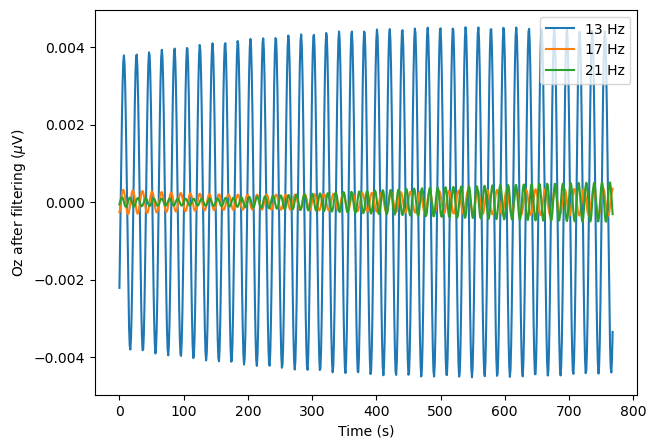

In [12]:
epochs = Epochs(
    raw_ext, events, event_id, tmin=2, tmax=5, baseline=None
).get_data(copy=False)

n_seconds = 3
time = np.linspace(0, n_seconds, n_seconds * sfreq,
                   endpoint=False)[np.newaxis, :]
channels = range(0, len(raw_ext.ch_names), len(raw.ch_names))
plt.figure(figsize=(7, 5))
for f, c in zip(frequencies, channels):
    plt.plot(epochs[5, c, :].T, label=str(int(f))+" Hz")
plt.xlabel("Time (s)")
plt.ylabel(r"Oz after filtering ($\mu$V)")
plt.legend(loc="upper right")
plt.show()

As it can be seen on this example, the subject is watching the 13Hz
stimulation and the EEG activity is showing an increase activity in this
frequency band while other frequencies have lower amplitudes.

## Spatial covariance for SSVEP

The covariance matrices will be estimated using the Ledoit-Wolf shrinkage
estimator on the extended signal.



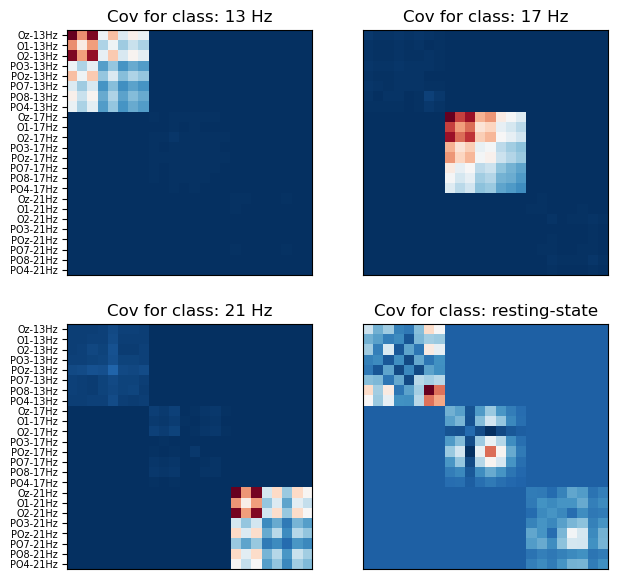

In [13]:
cov_ext_trials = BlockCovariances(
    estimator="lwf", block_size=8
).transform(epochs)

# This plot shows an example of a covariance matrix observed for each class:
ch_names = raw_ext.info["ch_names"]

plt.figure(figsize=(7, 7))
for i, l in enumerate(event_id):
    ax = plt.subplot(2, 2, i+1)
    plt.imshow(cov_ext_trials[events[:, 2] == event_id[l]][0],
               cmap=plt.get_cmap("RdBu_r"))
    plt.title("Cov for class: "+l)
    plt.xticks([])
    if i == 0 or i == 2:
        plt.yticks(np.arange(len(ch_names)), ch_names)
        ax.tick_params(axis="both", which="major", labelsize=7)
    else:
        plt.yticks([])
plt.show()

It appears clearly that each class yields a different structure of the
covariance matrix. Each stimulation (13, 17 and 21 Hz) generating higher
covariance values for EEG signal filtered at the proper bandwith and no
activation at all for the other bandwiths. The resting state, where the
subject focus on the center of the display and far from all blinking
stimulus, shows an activity with higher correlation in the 13Hz frequency
and lower but still visible activity in the other bandwiths.

## Classify with MDM
Plotting mean of each class



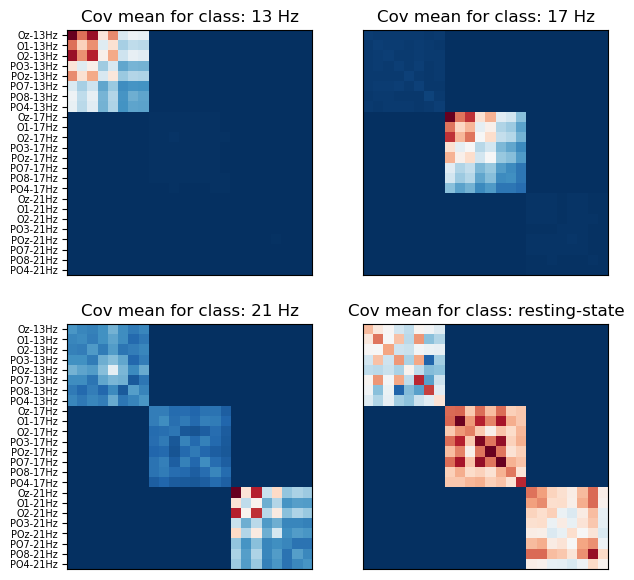

In [14]:
cov_centers = np.empty((len(event_id), 24, 24))
for i, l in enumerate(event_id):
    cov_centers[i] = mean_riemann(cov_ext_trials[events[:, 2] == event_id[l]])

plt.figure(figsize=(7, 7))
for i, l in enumerate(event_id):
    ax = plt.subplot(2, 2, i+1)
    plt.imshow(cov_centers[i], cmap=plt.get_cmap("RdBu_r"))
    plt.title("Cov mean for class: "+l)
    plt.xticks([])
    if i == 0 or i == 2:
        plt.yticks(np.arange(len(ch_names)), ch_names)
        ax.tick_params(axis="both", which="major", labelsize=7)
    else:
        plt.yticks([])
plt.show()

Minimum distance to mean is a simple and robust algorithm for BCI decoding.
It reproduces results of [2]_ for the first session of subject 12.



In [15]:
print("Number of trials: {}".format(len(cov_ext_trials)))

cv = RepeatedKFold(n_splits=2, n_repeats=10, random_state=42)
mdm = MDM(metric=dict(mean="riemann", distance="riemann"))
scores = cross_val_score(mdm, cov_ext_trials, events[:, 2], cv=cv, n_jobs=1)
print("MDM accuracy: {:.2f}% +/- {:.2f}".format(np.mean(scores)*100,
                                                np.std(scores)*100))
# The obtained results are 80.62% +/- 16.29 for this session, with a repeated
# 10-fold validation.

Number of trials: 32


/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/miniconda3/envs/obsidian/lib/python3.12/site-packages/pyriemann/utils/mean.py:641: UserWarning: Convergence not reached
/Users/rishabhkumar/

MDM accuracy: 80.94% +/- 16.23


## References
.. [1] [A New generation of Brain-Computer Interface Based on Riemannian
   Geometry](https://hal.archives-ouvertes.fr/hal-00879050)
   M. Congedo, A. Barachant, A. Andreev. Research report, 2013.
.. [2] [Review of Riemannian distances and divergences, applied to
   SSVEP-based BCI](https://hal.archives-ouvertes.fr/LISV/hal-03015762v1)
   S. Chevallier, E. K. Kalunga, Q. Barthélemy, E. Monacelli.
   Neuroinformatics, Springer, 2021, 19 (1), pp.93-106

